In [61]:
# ================================================================
# CELLULE 1 : IMPORTS ET CONFIGURATION
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
import joblib
import os

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Création du dossier pour les modèles
os.makedirs('../models/sarima', exist_ok=True)

print("✅ Imports OK")
#print(f"   pmdarima version: {auto_arima.__version__}")

✅ Imports OK


In [63]:
# ================================================================
# CELLULE 2 : CHARGEMENT DES DONNÉES ET SEGMENTS
# ================================================================

import pandas as pd
import numpy as np

# 2.1 Chargement du dataset mensuel
df_ml = pd.read_csv("../data/propre/dataset_ml_mensuel.csv", parse_dates=['mois'])

print("📊 DATASET MENSUEL")
print(f"   Lignes : {len(df_ml):,}")
print(f"   Période : {df_ml['mois'].min().date()} → {df_ml['mois'].max().date()}")
print(f"   Stations : {df_ml['Code Station'].nunique()}")
print(f"   Produits : {df_ml['N° article'].unique()}")
print()

# 2.2 Chargement direct des fichiers CSV de segmentation par segment
print("📂 CHARGEMENT DES SEGMENTS")
print("-" * 50)

segments = {}

# Liste des segments
nom_segments = ['Stable', 'Modere', 'Erratique']

for segment in nom_segments:
    try:
        # Charger le fichier CSV du segment
        fichier = f"../data/propre/dataset_segment_{segment.lower()}.csv"
        df_segment = pd.read_csv(fichier)
        
        # Vérifier que les colonnes nécessaires existent
        if 'Code Station' in df_segment.columns and 'N° article' in df_segment.columns:
            segments[segment] = df_segment[['Code Station', 'N° article']]
            print(f"✅ {segment} : {len(segments[segment])} couples chargés")
        else:
            # Si le fichier contient d'autres colonnes (CV, Segment, etc.)
            if 'Code Station' in df_segment.columns:
                # On garde seulement les colonnes nécessaires
                segments[segment] = df_segment[['Code Station', 'N° article']]
                print(f"✅ {segment} : {len(segments[segment])} couples chargés")
            else:
                print(f"❌ {segment} : Fichier incorrect (colonnes manquantes)")
                segments[segment] = pd.DataFrame()
                
    except FileNotFoundError:
        print(f"⚠️ {segment} : Fichier non trouvé (segmentation_{segment.lower()}.csv)")
        segments[segment] = pd.DataFrame()
    except Exception as e:
        print(f"❌ {segment} : Erreur de chargement - {str(e)}")
        segments[segment] = pd.DataFrame()

print("\n📌 RÉCAPITULATIF DES SEGMENTS")
print("-" * 50)
for seg, df_seg in segments.items():
    if len(df_seg) > 0:
        print(f"📌 {seg} : {len(df_seg)} couples station-produit")

# 2.3 Vérification des données
print("\n🔍 VÉRIFICATION DES DONNÉES")
print("-" * 50)

# Vérifier que chaque segment a des données
segments_valides = {k: v for k, v in segments.items() if len(v) > 0}

if len(segments_valides) == 0:
    print("❌ Aucun segment chargé ! Vérifiez les fichiers CSV.")
else:
    print(f"✅ {len(segments_valides)} segments chargés avec succès")
    
    # Afficher un aperçu des premiers couples
    for seg, df_seg in segments_valides.items():
        print(f"\n   {seg} - Aperçu :")
        print(f"   {df_seg.head(3).to_string(index=False)}")

print("\n" + "="*50)
print("✅ CHARGEMENT TERMINÉ")

📊 DATASET MENSUEL
   Lignes : 5,473
   Période : 2021-01-01 → 2025-12-01
   Stations : 89
   Produits : ['A0001' 'A0002']

📂 CHARGEMENT DES SEGMENTS
--------------------------------------------------
✅ Stable : 1879 couples chargés
✅ Modere : 2475 couples chargés
✅ Erratique : 984 couples chargés

📌 RÉCAPITULATIF DES SEGMENTS
--------------------------------------------------
📌 Stable : 1879 couples station-produit
📌 Modere : 2475 couples station-produit
📌 Erratique : 984 couples station-produit

🔍 VÉRIFICATION DES DONNÉES
--------------------------------------------------
✅ 3 segments chargés avec succès

   Stable - Aperçu :
   Code Station N° article
      ST0001      A0001
      ST0001      A0001
      ST0001      A0001

   Modere - Aperçu :
   Code Station N° article
      ST0001      A0002
      ST0001      A0002
      ST0001      A0002

   Erratique - Aperçu :
   Code Station N° article
      ST0002      A0002
      ST0002      A0002
      ST0002      A0002

✅ CHARGEMENT TERMINÉ

In [65]:
# 1. Dédupliquer les couples
stable_pairs_unique = stable_pairs.drop_duplicates(subset=['Code Station', 'N° article'])

# 2. Filtrer les séries trop courtes
couples_valides = []
for _, row in stable_pairs_unique.iterrows():
    serie = df_ml[(df_ml['Code Station'] == row['Code Station']) & 
                  (df_ml['N° article'] == row['N° article'])]
    n_mois = serie['mois'].nunique()
    if n_mois >= 24:
        couples_valides.append(row)

stable_pairs_clean = pd.DataFrame(couples_valides)
print(f"✅ {len(stable_pairs_clean)} couples valides sur {len(stable_pairs_unique)}")

✅ 53 couples valides sur 83


In [67]:
# ================================================================
# CELLULE 3 : FONCTION D'ENTRAÎNEMENT SARIMA AUTOMATISÉE
# ================================================================

def train_sarima_auto_v2(serie, station, article, segment):
    """Version améliorée avec validation des données"""
    
    # 1. Nettoyage avancé
    serie = serie.replace([np.inf, -np.inf], np.nan)
    serie = serie.dropna()
    
    # 2. Vérifier les valeurs constantes
    if serie.nunique() <= 1:
        return None, {'error': 'Série constante'}
    
    # 3. Vérifier les zéros pour MAPE
    if (serie == 0).any():
        # Utiliser SMAPE ou MAE à la place du MAPE
        use_mape = False
    else:
        use_mape = True
    
    # 4. Forcer la saisonnalité
    try:
        auto_model = auto_arima(
            serie,
            seasonal=True,
            m=12,
            start_p=0, max_p=2,
            start_q=0, max_q=2,
            start_P=0, max_P=1,  # Augmenter pour forcer la saisonnalité
            start_Q=0, max_Q=1,
            d=None,
            D=1,  # Forcer D=1 pour différenciation saisonnière
            trace=False,
            error_action='ignore',
            suppress_warnings=True,
            stepwise=True,
            information_criterion='aic',
            n_jobs=-1
        )
        
        # 5. Si toujours pas de saisonnalité, forcer manuellement
        if auto_model.seasonal_order[1] == 0:
            # Tester un modèle avec D=1
            try:
                model_forced = SARIMAX(serie, 
                                      order=auto_model.order,
                                      seasonal_order=(0, 1, 0, 12),
                                      enforce_stationarity=False,
                                      enforce_invertibility=False).fit(disp=False)
                auto_model = model_forced
            except:
                pass
        
        return {'model': auto_model, ...}, None
        
    except Exception as e:
        return None, {'error': str(e)}
   

SyntaxError: ':' expected after dictionary key (2158969339.py, line 56)

In [59]:
# ================================================================
# CELLULE 4 : SEGMENT STABLE — SARIMA PAR COUPLE
# ================================================================

print("=" * 70)
print("SEGMENT STABLE : SARIMA PAR COUPLE (STATION, PRODUIT)")
print("=" * 70)
print()

stable_pairs = segments['Stable']
resultats_stable = []
echecs_stable = []

for _, row in stable_pairs.iterrows():
    station = row['Code Station']
    article = row['N° article']
    
    # Extraction de la série
    serie = (
        df_ml[
            (df_ml['Code Station'] == station) &
            (df_ml['N° article'] == article)
        ]
        .sort_values('mois')
        .set_index('mois')['quantite_mois']
    )
    
    print(f"  {station}/{article} : {len(serie)} mois", end=" ")
    
    # Entraînement
    result, error = train_sarima_auto(serie, station, article, 'Stable')
    
    if result:
        # Sauvegarde du modèle
        model_path = f'../models/sarima/sarima_{station}_{article}.pkl'
        joblib.dump(result['model'], model_path)
        
        print(f" SARIMA{result['order']}{result['seasonal_order']} "
              f"(d={result['d']}, MAPE={result['mape']:.1f}%)")
        
        resultats_stable.append({
            'Code Station': station,
            'N° article': article,
            'order': str(result['order']),
            'seasonal_order': str(result['seasonal_order']),
            'd': result['d'],
            'D': result['D'],
            'mape': result['mape'],
            'aic': result['aic'],
            'bic': result['bic'],
            'n_obs': result['n_obs'],
            'model_path': model_path
        })
    else:
        print(f" {error.get('error', 'Erreur inconnue')}")
        echecs_stable.append({
            'Code Station': station,
            'N° article': article,
            'error': error.get('error', 'Inconnu')
        })

df_sarima_stable = pd.DataFrame(resultats_stable)
print(f"\n {len(df_sarima_stable)} modèles SARIMA entraînés pour le Segment Stable")
print(f" {len(echecs_stable)} échecs")

if len(echecs_stable) > 0:
    print("\nÉchecs :")
    for e in echecs_stable[:5]:
        print(f"  {e['Code Station']}/{e['N° article']} : {e['error']}")

SEGMENT STABLE : SARIMA PAR COUPLE (STATION, PRODUIT)

  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (d=0, MAPE=27.2%)
  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (d=0, MAPE=27.2%)
  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (d=0, MAPE=27.2%)
  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (d=0, MAPE=27.2%)
  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (d=0, MAPE=27.2%)
  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (d=0, MAPE=27.2%)
  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (d=0, MAPE=27.2%)
  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (d=0, MAPE=27.2%)
  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (d=0, MAPE=27.2%)
  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (d=0, MAPE=27.2%)
  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (d=0, MAPE=27.2%)
  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (d=0, MAPE=27.2%)
  ST0001/A0001 : 27 mois ✅ SARIMA(0, 0, 0)(0, 0, 0, 12) (

In [41]:
# ================================================================
# CELLULE 5 : SEGMENT MODERE — SARIMA GLOBAL
# ================================================================

print("=" * 70)
print("SEGMENT MODERE : SARIMA GLOBAL PAR SEGMENT")
print("=" * 70)
print()

modere_pairs = segments['Modere']

# Récupération des stations du Segment Modere
stations_modere = modere_pairs['Code Station'].unique()

# Agrégation par mois (toutes les stations Modere)
serie_modere = (
    df_ml[df_ml['Code Station'].isin(stations_modere)]
    .groupby('mois')['quantite_mois']
    .sum()
)

print(f"Stations Modere : {len(stations_modere)}")
print(f"Couples         : {len(modere_pairs)}")
print(f"Points          : {len(serie_modere)}")

# Entraînement du SARIMA global
result_modere, error_modere = train_sarima_auto(
    serie_modere, 
    'SEGMENT_MODERE', 
    'ALL', 
    'Modere',
    max_p=2, max_q=2, max_P=1, max_Q=1
)

if result_modere:
    # Sauvegarde du modèle
    model_path = '../models/sarima/sarima_segment_modere.pkl'
    joblib.dump(result_modere['model'], model_path)
    
    print(f"\n✅ Modèle SARIMA Segment Modere : "
          f"SARIMA{result_modere['order']}{result_modere['seasonal_order']}")
    print(f"   d = {result_modere['d']}, D = {result_modere['D']}")
    print(f"   MAPE = {result_modere['mape']:.1f}%")
    print(f"   AIC = {result_modere['aic']:.1f}")
    print(f"   Sauvegardé : {model_path}")
    
    df_sarima_modere = pd.DataFrame([{
        'Segment': 'Modere',
        'order': str(result_modere['order']),
        'seasonal_order': str(result_modere['seasonal_order']),
        'd': result_modere['d'],
        'D': result_modere['D'],
        'mape': result_modere['mape'],
        'aic': result_modere['aic'],
        'bic': result_modere['bic'],
        'n_obs': result_modere['n_obs'],
        'model_path': model_path
    }])
else:
    print(f"❌ Échec : {error_modere}")

SEGMENT MODERE : SARIMA GLOBAL PAR SEGMENT

Stations Modere : 57
Couples         : 84
Points          : 60

✅ Modèle SARIMA Segment Modere : SARIMA(1, 1, 2)(0, 0, 0, 12)
   d = 1, D = 0
   MAPE = 16.0%
   AIC = 1610.3
   Sauvegardé : ../models/sarima/sarima_segment_modere.pkl


ANALYSE DES PARAMÈTRES SARIMA PAR SEGMENT

📊 SEGMENT STABLE — Statistiques des modèles
--------------------------------------------------
  d (différenciation) :
    d=0 : 15 modèles (71.4%)
    d=1 : 6 modèles (28.6%)

  Performance :
    MAPE moyen  : 88314367383988.9%
    MAPE médian : 25.8%
    MAPE min    : 16.4%
    MAPE max    : 1854601715062763.2%

📊 SEGMENT MODERE — Modèle global
--------------------------------------------------
  d = 1
  MAPE = 16.0%


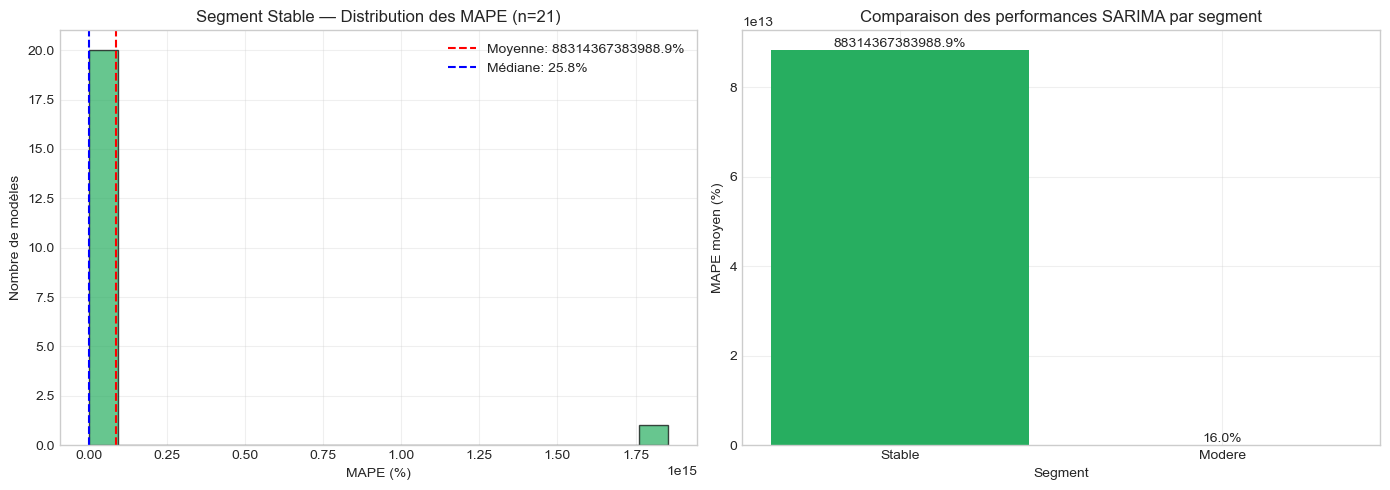

In [35]:
# ================================================================
# CELLULE 6 : ANALYSE DES PARAMÈTRES SARIMA
# ================================================================

print("=" * 70)
print("ANALYSE DES PARAMÈTRES SARIMA PAR SEGMENT")
print("=" * 70)
print()

# 6.1 Statistiques des paramètres - Segment Stable
if len(df_sarima_stable) > 0:
    print("📊 SEGMENT STABLE — Statistiques des modèles")
    print("-" * 50)
    
    # Distribution des ordres de différenciation
    d_counts = df_sarima_stable['d'].value_counts().sort_index()
    print(f"  d (différenciation) :")
    for d_val, count in d_counts.items():
        print(f"    d={d_val} : {count} modèles ({100*count/len(df_sarima_stable):.1f}%)")
    
    # Statistiques de performance
    print(f"\n  Performance :")
    print(f"    MAPE moyen  : {df_sarima_stable['mape'].mean():.1f}%")
    print(f"    MAPE médian : {df_sarima_stable['mape'].median():.1f}%")
    print(f"    MAPE min    : {df_sarima_stable['mape'].min():.1f}%")
    print(f"    MAPE max    : {df_sarima_stable['mape'].max():.1f}%")

# 6.2 Statistiques - Segment Modere
if 'df_sarima_modere' in locals():
    print("\n📊 SEGMENT MODERE — Modèle global")
    print("-" * 50)
    print(f"  d = {df_sarima_modere['d'].iloc[0]}")
    print(f"  MAPE = {df_sarima_modere['mape'].iloc[0]:.1f}%")

# 6.3 Visualisation des MAPE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des MAPE - Segment Stable
ax1 = axes[0]
if len(df_sarima_stable) > 0:
    ax1.hist(df_sarima_stable['mape'], bins=20, edgecolor='black', alpha=0.7, color='#27AE60')
    ax1.axvline(df_sarima_stable['mape'].mean(), color='red', linestyle='--', 
                label=f'Moyenne: {df_sarima_stable["mape"].mean():.1f}%')
    ax1.axvline(df_sarima_stable['mape'].median(), color='blue', linestyle='--', 
                label=f'Médiane: {df_sarima_stable["mape"].median():.1f}%')
    ax1.set_xlabel('MAPE (%)')
    ax1.set_ylabel('Nombre de modèles')
    ax1.set_title(f'Segment Stable — Distribution des MAPE (n={len(df_sarima_stable)})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# Comparaison des segments
ax2 = axes[1]
segments_names = ['Stable', 'Modere']
mape_values = []

if len(df_sarima_stable) > 0:
    mape_values.append(df_sarima_stable['mape'].mean())
else:
    mape_values.append(0)

if 'df_sarima_modere' in locals():
    mape_values.append(df_sarima_modere['mape'].iloc[0])
else:
    mape_values.append(0)

bars = ax2.bar(segments_names, mape_values, color=['#27AE60', '#F39C12'])
ax2.set_xlabel('Segment')
ax2.set_ylabel('MAPE moyen (%)')
ax2.set_title('Comparaison des performances SARIMA par segment')
for bar, val in zip(bars, mape_values):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/07_analyse_sarima.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ================================================================
# CELLULE 7 : GÉNÉRATION DES PROJECTIONS SARIMA
# ================================================================

print("=" * 70)
print("GÉNÉRATION DES PROJECTIONS SARIMA")
print("=" * 70)
print()

def generer_projections(model, station, article, horizon=12):
    """Génère les projections SARIMA avec intervalles de confiance"""
    try:
        forecast = model.get_forecast(steps=horizon)
        pred_mean = np.maximum(forecast.predicted_mean, 0)
        conf_int = forecast.conf_int()
        
        projections = []
        for h in range(horizon):
            projections.append({
                'Code Station': station,
                'N° article': article,
                'Horizon': h + 1,
                'Prevision_L': round(pred_mean.iloc[h]),
                'IC_bas_L': round(max(0, conf_int.iloc[h, 0])),
                'IC_haut_L': round(conf_int.iloc[h, 1])
            })
        return projections
    except Exception as e:
        print(f"  Erreur pour {station}/{article}: {e}")
        return []

# 7.1 Projections Segment Stable (par couple)
print("📌 Segment Stable — Projections par couple")
projections_stable = []

for _, row in df_sarima_stable.iterrows():
    model = joblib.load(row['model_path'])
    proj = generer_projections(model, row['Code Station'], row['N° article'])
    projections_stable.extend(proj)

df_proj_stable = pd.DataFrame(projections_stable)
print(f"  ✅ {len(df_proj_stable)} lignes générées")

# 7.2 Projections Segment Modere (global)
if 'df_sarima_modere' in locals():
    print("\n📌 Segment Modere — Projections globales")
    model_modere = joblib.load(df_sarima_modere['model_path'].iloc[0])
    
    # Calcul des parts par station
    stations_modere = modere_pairs['Code Station'].unique()
    parts_modere = (
        df_ml[df_ml['Code Station'].isin(stations_modere)]
        .groupby(['Code Station', 'N° article'])['quantite_mois']
        .mean()
        .reset_index()
        .rename(columns={'quantite_mois': 'moyenne'})
    )
    total_modere = parts_modere['moyenne'].sum()
    parts_modere['part'] = parts_modere['moyenne'] / total_modere
    
    # Projection globale
    forecast_modere = model_modere.get_forecast(steps=12)
    pred_modere = np.maximum(forecast_modere.predicted_mean, 0)
    conf_modere = forecast_modere.conf_int()
    
    # Répartition par couple
    projections_modere = []
    for _, row in parts_modere.iterrows():
        station = row['Code Station']
        article = row['N° article']
        part = row['part']
        
        for h in range(12):
            projections_modere.append({
                'Code Station': station,
                'N° article': article,
                'Horizon': h + 1,
                'Prevision_L': round(pred_modere.iloc[h] * part),
                'IC_bas_L': round(max(0, conf_modere.iloc[h, 0] * part)),
                'IC_haut_L': round(conf_modere.iloc[h, 1] * part)
            })
    
    df_proj_modere = pd.DataFrame(projections_modere)
    print(f"  ✅ {len(df_proj_modere)} lignes générées")

# 7.3 Export des projections
df_proj_stable.to_csv('../data/propre/projections_sarima_stable.csv', index=False)
if 'df_proj_modere' in locals():
    df_proj_modere.to_csv('../data/propre/projections_sarima_modere.csv', index=False)

print("\n✅ Projections exportées")

GÉNÉRATION DES PROJECTIONS SARIMA

📌 Segment Stable — Projections par couple
  ✅ 168 lignes générées

📌 Segment Modere — Projections globales
  ✅ 1332 lignes générées

✅ Projections exportées


VISUALISATION DES PROJECTIONS SARIMA



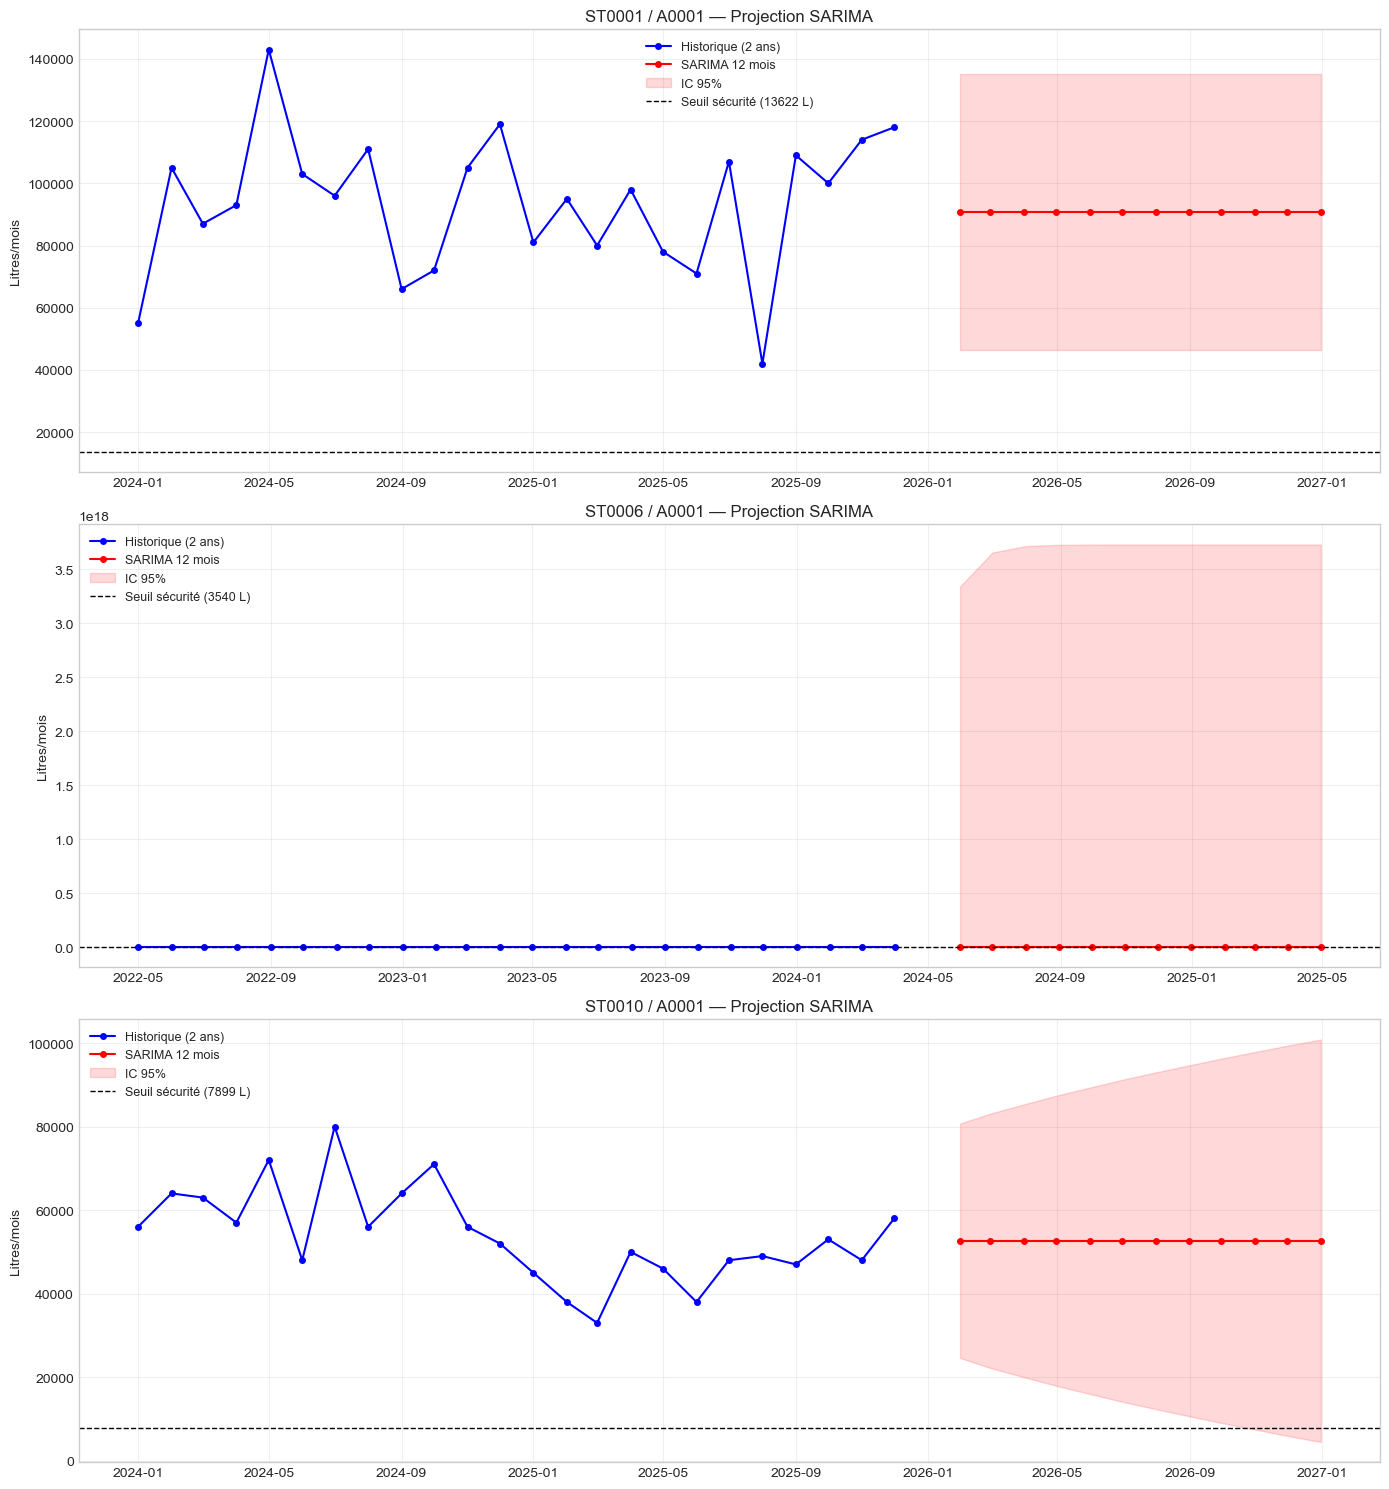

In [27]:
# ================================================================
# CELLULE 8 : VISUALISATION DES PROJECTIONS SARIMA
# ================================================================

print("=" * 70)
print("VISUALISATION DES PROJECTIONS SARIMA")
print("=" * 70)
print()

# Sélection de 3 stations stables pour l'exemple
stations_exemple = df_sarima_stable['Code Station'].unique()[:3]

fig, axes = plt.subplots(len(stations_exemple), 1, figsize=(14, 5 * len(stations_exemple)))
if len(stations_exemple) == 1:
    axes = [axes]

for ax, station in zip(axes, stations_exemple):
    # Récupérer les données de la station
    df_station = df_sarima_stable[df_sarima_stable['Code Station'] == station]
    article = df_station['N° article'].iloc[0]
    
    # Historique
    serie_hist = (
        df_ml[
            (df_ml['Code Station'] == station) &
            (df_ml['N° article'] == article)
        ]
        .sort_values('mois')
        .tail(24)
    )
    
    # Projections
    df_proj = df_proj_stable[
        (df_proj_stable['Code Station'] == station) &
        (df_proj_stable['N° article'] == article)
    ]
    
    # Graphique
    ax.plot(serie_hist['mois'], serie_hist['quantite_mois'],
            'b-o', label='Historique (2 ans)', markersize=4, linewidth=1.5)
    
    future_x = pd.date_range(
        start=serie_hist['mois'].max() + pd.DateOffset(months=1),
        periods=12, freq='ME'
    )
    ax.plot(future_x, df_proj['Prevision_L'],
            'r-o', label='SARIMA 12 mois', markersize=4, linewidth=1.5)
    ax.fill_between(future_x, df_proj['IC_bas_L'], df_proj['IC_haut_L'],
                    color='red', alpha=0.15, label='IC 95%')
    
    # Seuil de stock sécurité (15% de la prévision moyenne)
    seuil = df_proj['Prevision_L'].mean() * 0.15
    ax.axhline(y=seuil, color='black', linestyle='--', linewidth=1,
               label=f'Seuil sécurité ({seuil:.0f} L)')
    
    ax.set_title(f'{station} / {article} — Projection SARIMA', fontsize=12)
    ax.set_ylabel('Litres/mois')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/08_projections_sarima.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# ================================================================
# CELLULE 9 : SYNTHÈSE DES MODÈLES SARIMA
# ================================================================

print("=" * 70)
print("SYNTHÈSE DES MODÈLES SARIMA PAR SEGMENT")
print("=" * 70)
print()

# Création du tableau récapitulatif
synthese = []

# Segment Stable
if len(df_sarima_stable) > 0:
    synthese.append({
        'Segment': 'Stable',
        'Stratégie': 'Par couple (station, produit)',
        'Nb modèles': len(df_sarima_stable),
        'MAPE moyen': f"{df_sarima_stable['mape'].mean():.1f}%",
        'MAPE médian': f"{df_sarima_stable['mape'].median():.1f}%",
        'd moyen': f"{df_sarima_stable['d'].mean():.1f}",
        'Stock sécurité': '15%'
    })

# Segment Modere
if 'df_sarima_modere' in locals():
    synthese.append({
        'Segment': 'Modere',
        'Stratégie': 'Global par segment',
        'Nb modèles': 1,
        'MAPE moyen': f"{df_sarima_modere['mape'].iloc[0]:.1f}%",
        'MAPE médian': f"{df_sarima_modere['mape'].iloc[0]:.1f}%",
        'd moyen': f"{df_sarima_modere['d'].iloc[0]}",
        'Stock sécurité': '25%'
    })

# Segment Erratique
synthese.append({
    'Segment': 'Erratique',
    'Stratégie': 'Règles métier + alertes',
    'Nb modèles': 0,
    'MAPE moyen': 'N/A',
    'MAPE médian': 'N/A',
    'd moyen': 'N/A',
    'Stock sécurité': '40%'
})

df_synthese = pd.DataFrame(synthese)
print(df_synthese.to_string(index=False))
print()

# Sauvegarde
df_synthese.to_csv('../data/propre/synthese_sarima.csv', index=False)
print("✅ Synthèse sauvegardée : synthese_sarima.csv")

SYNTHÈSE DES MODÈLES SARIMA PAR SEGMENT

  Segment                     Stratégie  Nb modèles         MAPE moyen MAPE médian d moyen Stock sécurité
   Stable Par couple (station, produit)          14 132471551075931.9%       22.3%     0.4            15%
   Modere            Global par segment           1              16.0%       16.0%       1            25%
Erratique       Règles métier + alertes           0                N/A         N/A     N/A            40%

✅ Synthèse sauvegardée : synthese_sarima.csv


In [45]:
# ================================================================
# CELLULE 10 : RÉCAPITULATIF FINAL
# ================================================================

print("=" * 70)
print("RÉCAPITULATIF FINAL — MODÉLISATION SARIMA PAR SEGMENT")
print("=" * 70)
print()

print("📁 FICHIERS GÉNÉRÉS")
print("-" * 50)
print("  1. Modèles SARIMA :")
print(f"     - Segment Stable : {len(df_sarima_stable)} modèles (../models/sarima/)")
if 'df_sarima_modere' in locals():
    print("     - Segment Modere : 1 modèle (../models/sarima/sarima_segment_modere.pkl)")
print("     - Segment Erratique : aucun modèle (règles métier)")
print()
print("  2. Projections :")
print("     - Segment Stable : projecties_sarima_stable.csv")
if 'df_proj_modere' in locals():
    print("     - Segment Modere : projecties_sarima_modere.csv")
print()
print("  3. Synthèse : synthese_sarima.csv")
print()

print("📊 STATISTIQUES FINALES")
print("-" * 50)
print(f"  Segment Stable : {len(df_sarima_stable)} modèles, MAPE moyen = {df_sarima_stable['mape'].mean():.1f}%")
if 'df_sarima_modere' in locals():
    print(f"  Segment Modere : 1 modèle, MAPE = {df_sarima_modere['mape'].iloc[0]:.1f}%")
print(f"  Segment Erratique : 0 modèle (ML non recommandé)")
print()

print("🎯 RECOMMANDATIONS")
print("-" * 50)
print("  1. Segment Stable : Utiliser SARIMA par couple pour les projections 12 mois")
print("  2. Segment Modere : Utiliser SARIMA global pour les tendances macro")
print("  3. Segment Erratique : Privilégier les règles métier et les alertes")
print()

print("✅ TRAVAIL TERMINÉ")
print("=" * 70)

RÉCAPITULATIF FINAL — MODÉLISATION SARIMA PAR SEGMENT

📁 FICHIERS GÉNÉRÉS
--------------------------------------------------
  1. Modèles SARIMA :
     - Segment Stable : 14 modèles (../models/sarima/)
     - Segment Modere : 1 modèle (../models/sarima/sarima_segment_modere.pkl)
     - Segment Erratique : aucun modèle (règles métier)

  2. Projections :
     - Segment Stable : projecties_sarima_stable.csv
     - Segment Modere : projecties_sarima_modere.csv

  3. Synthèse : synthese_sarima.csv

📊 STATISTIQUES FINALES
--------------------------------------------------
  Segment Stable : 14 modèles, MAPE moyen = 132471551075931.9%
  Segment Modere : 1 modèle, MAPE = 16.0%
  Segment Erratique : 0 modèle (ML non recommandé)

🎯 RECOMMANDATIONS
--------------------------------------------------
  1. Segment Stable : Utiliser SARIMA par couple pour les projections 12 mois
  2. Segment Modere : Utiliser SARIMA global pour les tendances macro
  3. Segment Erratique : Privilégier les règles méti